# 🌸 Menstrual Cycle Risk Analysis — Adaptive Edition

**What makes this version smarter:**
- ✅ Thresholds are **learned from your actual data** (no magic numbers)
- ✅ Risk is compared to **each person's own history**, not a global average
- ✅ Explanations are **generated dynamically** with real numbers from each record

> 💙 For awareness only — not medical advice. If anything feels off, talk to a trusted adult or doctor.

---
## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import shap   
import joblib

print(' Libraries loaded')

 Libraries loaded


---
## Cell 2 — Load Raw Data + Preprocessing (same as training notebook)

In [2]:
df_raw = pd.read_csv('menstrual_data.csv')
df     = df_raw.copy()

df['LengthofCycle'] = pd.to_numeric(df['LengthofCycle'], errors='coerce')
df['LengthofCycle'].fillna(df['LengthofCycle'].median(), inplace=True)

df['baseline']          = df['LengthofCycle'].rolling(window=3, min_periods=1).mean()
df['target_adjustment'] = df['LengthofCycle'] - df['baseline']

drop_cols = [
    'ClientID',
    'CycleNumber',

    # duplicate encoded
    'AgeM','MaristatusM','ReligionM','EthnicityM',
    'SchoolyearsM','MedvitsM','MedvitexplainM',
    'LivingkidsM','SpousesameM','NextpregM',

    # text / noisy
    'Medvitexplain','Whychart','Methoddate',
        'Religion','Ethnicity','OccupationM','IncomeM',

    'MensesScoreDay10','MensesScoreDay11','MensesScoreDay12',
    'MensesScoreDay13','MensesScoreDay14','MensesScoreDay15',
    'MensesScoreDayEight',

    'MensesScoreDayFour','MensesScoreDayFive',
    'MensesScoreDaySix','MensesScoreDayNine',

    'Medvits',

    'Group','CycleWithPeakorNot','ReproductiveCategory'
]
leak_cols = [
    'MeanCycleLength','EstimatedDayofOvulation',
    'LengthofLutealPhase','TotalDaysofFertility','TotalFertilityFormula'
]
df.drop(columns=drop_cols + leak_cols, inplace=True, errors='ignore')

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['LengthofCycle', 'target_adjustment'], errors='ignore')
y = df['target_adjustment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f' Data ready → {df.shape[0]} rows, {X.shape[1]} features')

 Data ready → 1665 rows, 42 features


---
## Cell 3 — Load / Train Model

In [3]:
try:
    model = joblib.load('menstrual_model.joblib')
    print(' Loaded existing model')
except FileNotFoundError:
    print('Re-training...')
    model = RandomForestRegressor(
        n_estimators=150, max_depth=10,
        min_samples_split=5, min_samples_leaf=2, random_state=42
    )
    model.fit(X_train, y_train)
    joblib.dump(model, 'menstrual_model.joblib')
    print(' Trained and saved')

y_pred_adj    = model.predict(X_test)
baseline_test = df.loc[X_test.index, 'baseline']
final_pred    = baseline_test + y_pred_adj
actual        = df.loc[X_test.index, 'LengthofCycle']

print(f'Test MAE: {mean_absolute_error(actual, final_pred):.2f} days')

 Loaded existing model
Test MAE: 1.67 days


---
## Cell 4 — 📊 Learn Thresholds FROM the Data

Instead of hardcoding `< 21` or `> 35`, we compute:
- **Population thresholds** — 5th / 95th percentile of the whole dataset
- **Per-person thresholds** — each person's own mean ± 2 standard deviations
- **Bleeding thresholds** — percentile-based from the actual distribution

This means the flags adapt automatically if you replace the CSV with a different dataset.

In [4]:
# ── 4a. Population-level thresholds ──────────────────────────────────────────
cycles = pd.to_numeric(df_raw['LengthofCycle'], errors='coerce').dropna()

POP_THRESHOLDS = {
    'cycle_low'  : cycles.quantile(0.05),   # bottom 5% of the dataset
    'cycle_high' : cycles.quantile(0.95),   # top 5%
    'cycle_mean' : cycles.mean(),
    'cycle_std'  : cycles.std(),
}

# ── 4b. Bleeding thresholds ───────────────────────────────────────────────────
mbi_raw = pd.to_numeric(df_raw['MeanBleedingIntensity'], errors='coerce').dropna()
lom_raw = pd.to_numeric(df_raw['LengthofMenses'],        errors='coerce').dropna()

BLEED_THRESHOLDS = {
    'heavy_intensity' : mbi_raw.quantile(0.85),  # top 15% = heavy
    'long_menses'     : lom_raw.quantile(0.90),  # top 10% = very long period
    'menses_mean'     : lom_raw.mean(),
    'intensity_mean'  : mbi_raw.mean(),
}

# ── 4c. Per-person history (using the TRAINING set only to avoid leakage) ─────
# We build a lookup: ClientID → {mean, std, upper, lower} from their history
if 'ClientID' in df_raw.columns:
    person_stats = (
        df_raw.assign(LengthofCycle=pd.to_numeric(df_raw['LengthofCycle'], errors='coerce'))
        .groupby('ClientID')['LengthofCycle']
        .agg(['mean', 'std', 'count'])
        .rename(columns={'mean':'personal_mean', 'std':'personal_std', 'count':'n_cycles'})
    )
    # For people with only 1 cycle, std is NaN — fall back to population std
    person_stats['personal_std'] = person_stats['personal_std'].fillna(POP_THRESHOLDS['cycle_std'])
    # Upper/lower personal bounds = mean ± 2 SD
    person_stats['personal_upper'] = person_stats['personal_mean'] + 2 * person_stats['personal_std']
    person_stats['personal_lower'] = person_stats['personal_mean'] - 2 * person_stats['personal_std']
    PERSON_STATS_AVAILABLE = True
else:
    PERSON_STATS_AVAILABLE = False
    print('⚠️  ClientID not in dataset — will use population thresholds only')

# ── Print what was learned ────────────────────────────────────────────────────
print('📊 Learned Population Thresholds:')
print(f"  Cycle length — low flag  : < {POP_THRESHOLDS['cycle_low']:.1f} days  (5th percentile)")
print(f"  Cycle length — high flag : > {POP_THRESHOLDS['cycle_high']:.1f} days  (95th percentile)")
print(f"  Period too long          : > {BLEED_THRESHOLDS['long_menses']:.1f} days  (90th percentile)")
print(f"  Bleeding intensity heavy : > {BLEED_THRESHOLDS['heavy_intensity']:.2f}  (85th percentile)")
if PERSON_STATS_AVAILABLE:
    print(f'  Per-person bounds        : individual mean ± 2 SD (from {len(person_stats)} people)')

📊 Learned Population Thresholds:
  Cycle length — low flag  : < 25.0 days  (5th percentile)
  Cycle length — high flag : > 37.0 days  (95th percentile)
  Period too long          : > 7.0 days  (90th percentile)
  Bleeding intensity heavy : > 12.00  (85th percentile)
  Per-person bounds        : individual mean ± 2 SD (from 159 people)


---
## Cell 5 — 🏗️ Adaptive Risk Engine

The `assess_risk_adaptive()` function:
1. Pulls **this person's own history** from `person_stats`
2. Flags using **their personal bounds first**, then population bounds as fallback
3. Writes explanations that include the **actual numbers** (not generic strings)

In [5]:
def _explain_cycle_length(cycle, personal_mean, personal_lower, personal_upper,
                           pop_low, pop_high, deviation, n_cycles):
    """
    Generate a dynamic, number-filled explanation for cycle length flags.
    Adapts wording depending on how extreme the value is and how much
    personal history is available.
    """
    flags, reasons = [], []

    # --- Short cycle ---
    if cycle < personal_lower:
        severity = 'quite a bit' if cycle < personal_lower - 5 else 'a little'
        flags.append('SHORT_CYCLE')
        if n_cycles >= 3:
            reasons.append(
                f'⏩ SHORT CYCLE — predicted {cycle:.0f} days, but your personal '
                f'normal range (based on your last {n_cycles} cycles) is '
                f'{personal_lower:.0f}–{personal_upper:.0f} days. '
                f'This is {severity} shorter than usual for YOU specifically. '
                f'Short cycles are often caused by stress, disrupted sleep, or '
                f'changes in diet — especially common in teen years.'
            )
        else:
            reasons.append(
                f'⏩ SHORT CYCLE — predicted {cycle:.0f} days, which falls below '
                f'the typical range of {pop_low:.0f}–{pop_high:.0f} days seen '
                f'in this dataset. We don\'t have much of your personal history '
                f'yet ({n_cycles} cycle(s) logged), so this is compared to the '
                f'general population for now.'
            )
    # --- Long cycle ---
    elif cycle > personal_upper:
        severity = 'significantly' if cycle > personal_upper + 7 else 'somewhat'
        flags.append('LONG_CYCLE')
        if n_cycles >= 3:
            reasons.append(
                f'⏳ LONG CYCLE — predicted {cycle:.0f} days, which is {severity} '
                f'above your personal normal range of '
                f'{personal_lower:.0f}–{personal_upper:.0f} days. '
                f'Longer cycles are very normal in the first few years of periods. '
                f'They can also be linked to stress, changes in weight, or hormonal shifts.'
            )
        else:
            reasons.append(
                f'⏳ LONG CYCLE — predicted {cycle:.0f} days, which is above the '
                f'typical upper range of {pop_high:.0f} days in this dataset. '
                f'Only {n_cycles} cycle(s) logged so far, so we\'re using population '
                f'norms as a reference.'
            )

    # --- Irregular vs personal baseline ---
    # Only fire if cycle length is technically within population bounds
    # but still far from THIS person's normal
    if deviation > (2 * personal_mean * 0.10) and 'SHORT_CYCLE' not in flags and 'LONG_CYCLE' not in flags:
        flags.append('IRREGULAR')
        pct_change = (deviation / personal_mean) * 100
        reasons.append(
            f'📊 IRREGULAR — this cycle ({cycle:.0f} days) differs from your '
            f'personal average ({personal_mean:.0f} days) by {deviation:.0f} days '
            f'({pct_change:.0f}%). That\'s more variability than usual. '
            f'Occasional irregular cycles are totally normal, especially during '
            f'stressful periods like exams, travel, or illness.'
        )

    return flags, reasons


def _explain_bleeding(raw_idx, lom_threshold, mbi_threshold, lom_mean, mbi_mean):
    """Dynamic explanations for period length and bleeding intensity."""
    flags, reasons = [], []

    try:
        lom = float(df_raw.loc[raw_idx, 'LengthofMenses'])
        if lom > lom_threshold:
            extra = lom - lom_mean
            flags.append('VERY_LONG_PERIOD')
            reasons.append(
                f'🗓️ LONG PERIOD — your period lasted {lom:.0f} days, which is '
                f'{extra:.1f} days more than average ({lom_mean:.1f} days) and '
                f'above the 90th percentile for this dataset ({lom_threshold:.1f} days). '
                f'Periods lasting this long are worth mentioning to a doctor, '
                f'especially if they feel heavy too.'
            )
    except (KeyError, ValueError, TypeError):
        pass

    try:
        mbi = float(df_raw.loc[raw_idx, 'MeanBleedingIntensity'])
        if mbi > mbi_threshold:
            pct_above = ((mbi - mbi_mean) / mbi_mean) * 100
            flags.append('HEAVY_BLEEDING')
            reasons.append(
                f'💧 HEAVY BLEEDING — your average bleeding intensity was {mbi:.2f}, '
                f'which is {pct_above:.0f}% above the dataset average ({mbi_mean:.2f}) '
                f'and in the top 15% of all records. '
                f'Heavy bleeding can cause low iron and tiredness. '
                f'If you are soaking through a pad or tampon every hour, '
                f'it is worth talking to a doctor.'
            )
    except (KeyError, ValueError, TypeError):
        pass

    try:
        ub = float(df_raw.loc[raw_idx, 'UnusualBleeding'])
        if ub > 0:
            flags.append('UNUSUAL_BLEEDING')
            reasons.append(
                f'🔴 UNUSUAL BLEEDING — there was some bleeding outside your '
                f'regular period (value: {ub:.0f}). Mid-cycle spotting can be '
                f'completely harmless (it sometimes happens around ovulation), '
                f'but if it keeps happening it is worth mentioning to a doctor.'
            )
    except (KeyError, ValueError, TypeError):
        pass

    return flags, reasons


def assess_risk_adaptive(row_index, predicted_cycle, baseline_val,
                          pop_thresh, bleed_thresh, person_stats_df):
    """
    Full adaptive risk assessment for one record.
    Uses personal history when available, falls back to population norms.
    """
    # ── Get personal stats ────────────────────────────────────────────────────
    client_id = df_raw.loc[row_index, 'ClientID'] if 'ClientID' in df_raw.columns else None

    if client_id and client_id in person_stats_df.index:
        ps          = person_stats_df.loc[client_id]
        p_mean      = ps['personal_mean']
        p_std       = ps['personal_std']
        p_lower     = ps['personal_lower']
        p_upper     = ps['personal_upper']
        n_cycles    = int(ps['n_cycles'])
        using_personal = True
    else:
        # Fall back to population stats
        p_mean      = pop_thresh['cycle_mean']
        p_std       = pop_thresh['cycle_std']
        p_lower     = pop_thresh['cycle_low']
        p_upper     = pop_thresh['cycle_high']
        n_cycles    = 0
        using_personal = False

    deviation = abs(predicted_cycle - p_mean)

    # ── Run flag checks ───────────────────────────────────────────────────────
    cycle_flags, cycle_reasons = _explain_cycle_length(
        predicted_cycle, p_mean, p_lower, p_upper,
        pop_thresh['cycle_low'], pop_thresh['cycle_high'],
        deviation, n_cycles
    )
    bleed_flags, bleed_reasons = _explain_bleeding(
        row_index,
        bleed_thresh['long_menses'],
        bleed_thresh['heavy_intensity'],
        bleed_thresh['menses_mean'],
        bleed_thresh['intensity_mean'],
    )

    all_flags   = cycle_flags + bleed_flags
    all_reasons = cycle_reasons + bleed_reasons

    # ── Risk level ────────────────────────────────────────────────────────────
    n = len(all_flags)
    if n == 0:
        risk_level = 'LOW '
        summary    = '✨ Everything looks normal for this cycle. Keep tracking!'
    elif n == 1:
        risk_level = 'MODERATE '
        summary    = f'👀 One thing to keep an eye on: {all_flags[0].replace("_"," ").title()}.'
    else:
        risk_level = 'HIGH '
        flag_str   = ', '.join(f.replace('_',' ').title() for f in all_flags)
        summary    = f'⚠️ {n} things flagged: {flag_str}. Might be worth talking to someone you trust.'

    return {
        'predicted_cycle' : round(predicted_cycle, 1),
        'personal_mean'   : round(p_mean, 1),
        'personal_lower'  : round(p_lower, 1),
        'personal_upper'  : round(p_upper, 1),
        'deviation'       : round(deviation, 1),
        'n_cycles_known'  : n_cycles,
        'using_personal'  : using_personal,
        'risk_level'      : risk_level,
        'flags'           : all_flags,
        'summary'         : summary,
        'reasons'         : all_reasons,
    }

print('Adaptive risk engine ready')

Adaptive risk engine ready


---
## Cell 6 — Run Risk Assessment on the Full Test Set

In [6]:
ps_df = person_stats if PERSON_STATS_AVAILABLE else pd.DataFrame()

results = []
for idx in X_test.index:
    r = assess_risk_adaptive(
        row_index      = idx,
        predicted_cycle= float(final_pred[idx]),
        baseline_val   = float(baseline_test[idx]),
        pop_thresh     = POP_THRESHOLDS,
        bleed_thresh   = BLEED_THRESHOLDS,
        person_stats_df= ps_df,
    )
    r['index'] = idx
    results.append(r)

results_df = pd.DataFrame(results).set_index('index')

print('📊 Risk Level Distribution:')
print(results_df['risk_level'].value_counts().to_string())
print(f'\n Records using personal history : {results_df["using_personal"].sum()}')
print(f' Records using population norms  : {(~results_df["using_personal"]).sum()}')

📊 Risk Level Distribution:
risk_level
LOW          308
MODERATE      19
HIGH           6

 Records using personal history : 333
 Records using population norms  : 0


---
## Cell 7 — Visualisations 

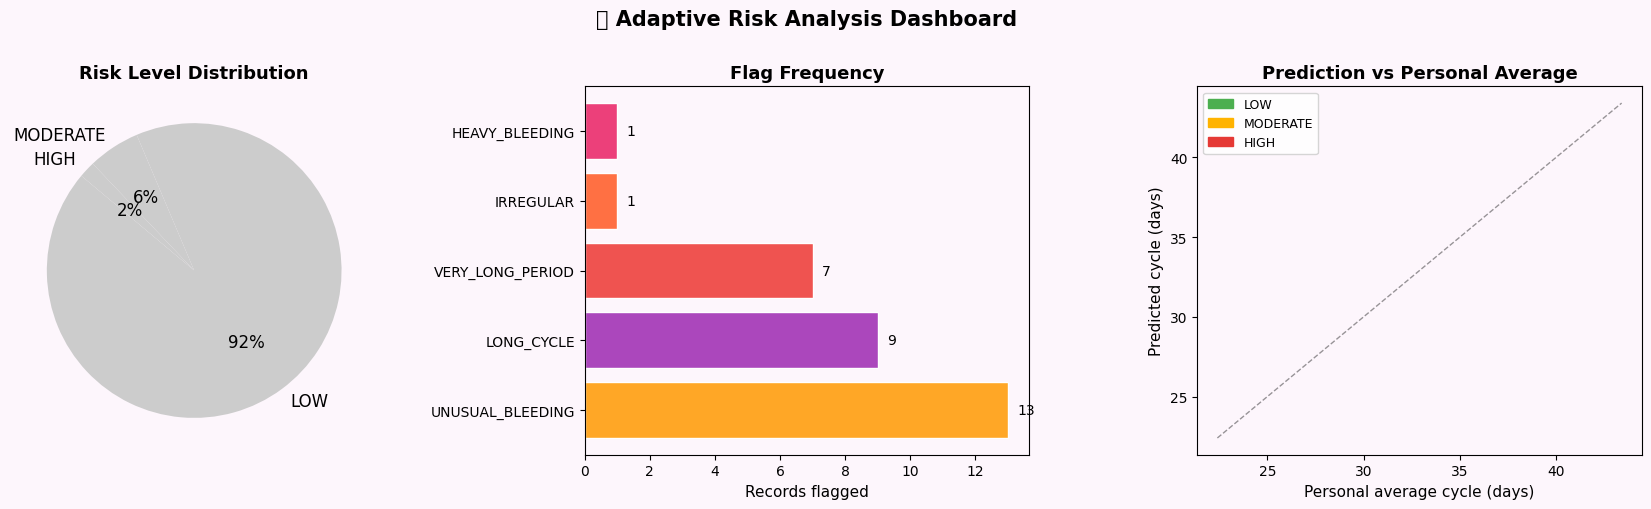

Saved → risk_adaptive_dashboard.png


In [7]:
color_map  = {'LOW 🟢': '#4caf50', 'MODERATE 🟡': '#ffb300', 'HIGH 🔴': '#e53935'}
flag_color = {
    'SHORT_CYCLE'     : '#42a5f5',
    'LONG_CYCLE'      : '#ab47bc',
    'IRREGULAR'       : '#ff7043',
    'VERY_LONG_PERIOD': '#ef5350',
    'HEAVY_BLEEDING'  : '#ec407a',
    'UNUSUAL_BLEEDING': '#ffa726',
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor('#fdf6fc')

# ── 1. Risk pie ───────────────────────────────────────────────────────────────
rc = results_df['risk_level'].value_counts()
axes[0].pie(
    rc.values,
    labels=[r.split()[0] for r in rc.index],
    autopct='%1.0f%%',
    colors=[color_map.get(k, '#ccc') for k in rc.index],
    startangle=140, textprops={'fontsize': 12}
)
axes[0].set_title('Risk Level Distribution', fontsize=13, fontweight='bold')

# ── 2. Flag bar chart ─────────────────────────────────────────────────────────
all_flags   = [f for fl in results_df['flags'] for f in fl]
flag_counts = pd.Series(all_flags).value_counts()
bcolors     = [flag_color.get(f, '#90caf9') for f in flag_counts.index]
axes[1].barh(flag_counts.index, flag_counts.values, color=bcolors, edgecolor='white')
axes[1].set_xlabel('Records flagged', fontsize=11)
axes[1].set_title('Flag Frequency', fontsize=13, fontweight='bold')
axes[1].set_facecolor('#fdf6fc')
for i, v in enumerate(flag_counts.values):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=10)

# ── 3. Personal vs population comparison scatter ───────────────────────────────
axes[2].scatter(
    results_df['personal_mean'],
    results_df['predicted_cycle'],
    c=results_df['risk_level'].map(color_map),
    alpha=0.7, s=40, edgecolors='white', linewidths=0.4
)
# diagonal line = prediction equals personal mean (perfect match)
lims = [min(results_df['personal_mean'].min(), results_df['predicted_cycle'].min()) - 1,
        max(results_df['personal_mean'].max(), results_df['predicted_cycle'].max()) + 1]
axes[2].plot(lims, lims, 'k--', lw=1, alpha=0.4, label='Pred = personal avg')
axes[2].set_xlabel('Personal average cycle (days)', fontsize=11)
axes[2].set_ylabel('Predicted cycle (days)', fontsize=11)
axes[2].set_title('Prediction vs Personal Average', fontsize=13, fontweight='bold')
axes[2].set_facecolor('#fdf6fc')
patches = [mpatches.Patch(color=v, label=k.split()[0]) for k,v in color_map.items()]
axes[2].legend(handles=patches, fontsize=9)

plt.suptitle('🌸 Adaptive Risk Analysis Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('risk_adaptive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → risk_adaptive_dashboard.png')

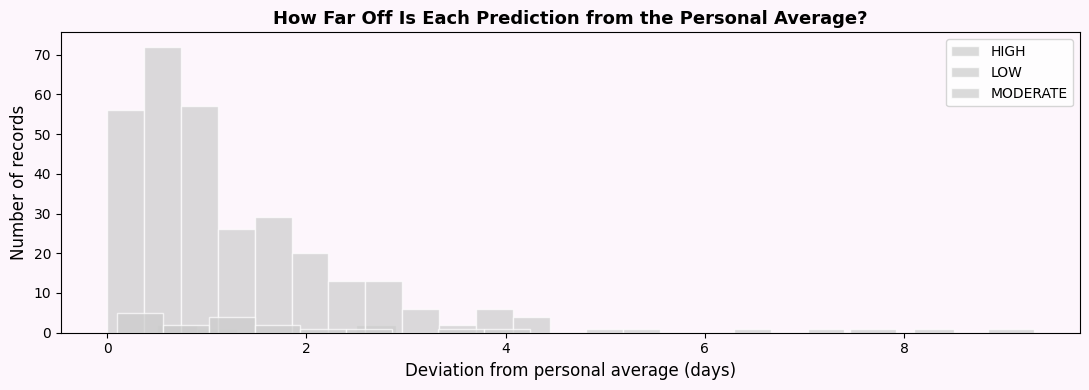

In [8]:
# ── Distribution of deviations — coloured by risk ────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor('#fdf6fc')
ax.set_facecolor('#fdf6fc')

for level, grp in results_df.groupby('risk_level'):
    ax.hist(
        grp['deviation'], bins=20,
        color=color_map.get(level, '#ccc'),
        alpha=0.7, label=level.split()[0], edgecolor='white'
    )

ax.set_xlabel('Deviation from personal average (days)', fontsize=12)
ax.set_ylabel('Number of records', fontsize=12)
ax.set_title('How Far Off Is Each Prediction from the Personal Average?', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('deviation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 8 — SHAP: Why Did the Model Predict This?

⏳ Computing SHAP values...
✅ Done!


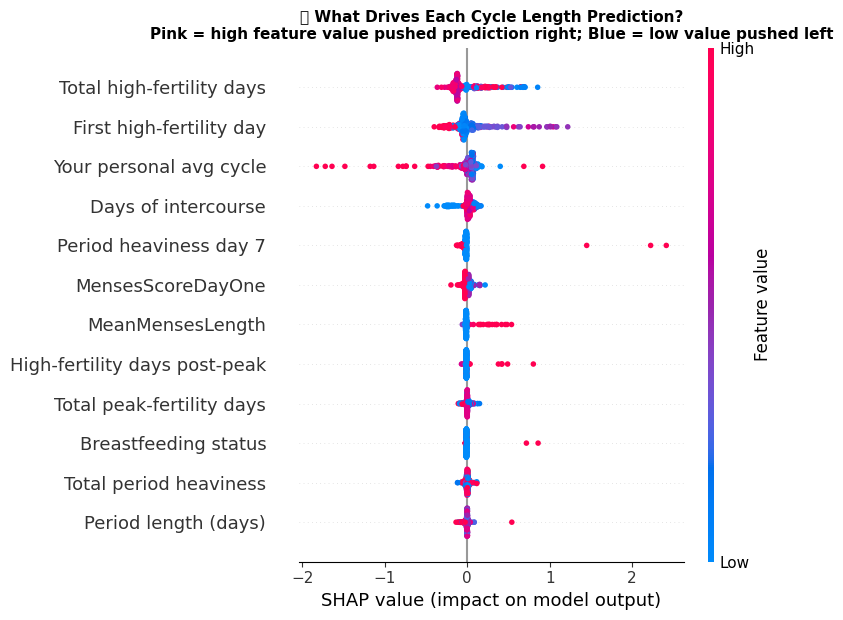

In [9]:
print('⏳ Computing SHAP values...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print('✅ Done!')

# Friendly feature names for the chart
FRIENDLY = {
    'baseline'                  : 'Your personal avg cycle',
    'FirstDayofHigh'            : 'First high-fertility day',
    'TotalNumberofHighDays'     : 'Total high-fertility days',
    'TotalMensesScore'          : 'Total period heaviness',
    'NumberofDaysofIntercourse' : 'Days of intercourse',
    'MensesScoreDaySeven'       : 'Period heaviness day 7',
    'TotalNumberofPeakDays'     : 'Total peak-fertility days',
    'LengthofMenses'            : 'Period length (days)',
    'TotalHighPostPeak'         : 'High-fertility days post-peak',
    'Gynosurgeries'             : 'Gynaecological surgery history',
    'Breastfeeding'             : 'Breastfeeding status',
    'Age'                       : 'Age',
    'BMI'                       : 'BMI',
}

X_test_display = X_test.rename(columns=FRIENDLY)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_display, max_display=12, show=False)
plt.title('🔍 What Drives Each Cycle Length Prediction?\n'
          'Pink = high feature value pushed prediction right; Blue = low value pushed left',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 9 — 📋 Per-Person Risk Report

Run this cell for any test-set index to get a full, dynamic report.

In [10]:
def print_report(sample_index):
    """Print a complete adaptive risk report for one record."""
    if sample_index not in results_df.index:
        print(f'❌ Index {sample_index} not in test set.')
        return

    risk = results_df.loc[sample_index]
    pos  = list(X_test.index).index(sample_index)

    W = 62
    print('═' * W)
    print('  🌸 PERSONAL CYCLE RISK REPORT')
    print('═' * W)

    # ── Context block ─────────────────────────────────────────────────────────
    src = 'your own history' if risk['using_personal'] else 'population averages'
    print(f"  Predicted cycle      : {risk['predicted_cycle']} days")
    print(f"  Your normal range    : {risk['personal_lower']}–{risk['personal_upper']} days")
    print(f"  Your average         : {risk['personal_mean']} days")
    print(f"  Deviation            : {risk['deviation']} days from your average")
    print(f"  Cycles on record     : {risk['n_cycles_known']}")
    print(f"  Thresholds based on  : {src}")
    print(f"  Overall risk         : {risk['risk_level']}")
    print()
    print(f"  {risk['summary']}")

    # ── Flag explanations ──────────────────────────────────────────────────────
    if risk['reasons']:
        print()
        print('─' * W)
        print('  📌 Detailed explanations')
        print('─' * W)
        for i, reason in enumerate(risk['reasons'], 1):
            wrapped = textwrap.fill(reason, width=56, subsequent_indent='      ')
            print(f'  {i}. {wrapped}')
            print()

    # ── SHAP explanation ───────────────────────────────────────────────────────
    shap_row = pd.Series(shap_values[pos], index=X_test.columns)
    top5     = shap_row.abs().sort_values(ascending=False).head(5)
    top5_dir = shap_row.loc[top5.index]

    print('─' * W)
    print('  🔍 Why the model predicted this cycle length')
    print('     (top 5 factors, from your data)')
    print('─' * W)
    for feat, impact in top5_dir.items():
        direction = f'↑ +{abs(impact):.2f} days (pushed longer)' if impact > 0 \
                    else f'↓ −{abs(impact):.2f} days (pushed shorter)'
        fname = FRIENDLY.get(feat, feat)
        print(f'  • {fname}')
        print(f'    {direction}')
        print()

    print('─' * W)
    print('  💙 This is an awareness tool, not medical advice.')
    print('     Talk to a doctor or trusted adult if anything')
    print('     feels off. You\'re doing great by tracking! 🌷')
    print('═' * W)


# ── Demo runs ──────────────────────────────────────────────────────────────────
high_risk = results_df[results_df['risk_level'].str.startswith('HIGH')]
low_risk  = results_df[results_df['risk_level'].str.startswith('LOW')]

if not high_risk.empty:
    print('\n🔴 HIGH-RISK example:\n')
    print_report(high_risk.index[0])

if not low_risk.empty:
    print('\n\n🟢 LOW-RISK example:\n')
    print_report(low_risk.index[0])


🔴 HIGH-RISK example:

══════════════════════════════════════════════════════════════
  🌸 PERSONAL CYCLE RISK REPORT
══════════════════════════════════════════════════════════════
  Predicted cycle      : 30.2 days
  Your normal range    : 21.7–37.5 days
  Your average         : 29.6 days
  Deviation            : 0.6 days from your average
  Cycles on record     : 11
  Thresholds based on  : your own history
  Overall risk         : HIGH 

  ⚠️ 2 things flagged: Very Long Period, Unusual Bleeding. Might be worth talking to someone you trust.

──────────────────────────────────────────────────────────────
  📌 Detailed explanations
──────────────────────────────────────────────────────────────
  1. 🗓️ LONG PERIOD — your period lasted 8 days, which is 2.8
      days more than average (5.2 days) and above the
      90th percentile for this dataset (7.0 days).
      Periods lasting this long are worth mentioning to
      a doctor, especially if they feel heavy too.

  2. 🔴 UNUSUAL BLEEDING 

---
## Cell 10 — Enter a Custom Index to Get a Report

Change `SAMPLE_INDEX` to any index from `X_test.index` to see a report for that record.

In [11]:
SAMPLE_INDEX = X_test.index[0]   # ← change this to any index you want
print_report(SAMPLE_INDEX)

══════════════════════════════════════════════════════════════
  🌸 PERSONAL CYCLE RISK REPORT
══════════════════════════════════════════════════════════════
  Predicted cycle      : 30.5 days
  Your normal range    : 25.9–36.0 days
  Your average         : 30.9 days
  Deviation            : 0.4 days from your average
  Cycles on record     : 16
  Thresholds based on  : your own history
  Overall risk         : LOW 

  ✨ Everything looks normal for this cycle. Keep tracking!
──────────────────────────────────────────────────────────────
  🔍 Why the model predicted this cycle length
     (top 5 factors, from your data)
──────────────────────────────────────────────────────────────
  • First high-fertility day
    ↑ +0.25 days (pushed longer)

  • Days of intercourse
    ↓ −0.19 days (pushed shorter)

  • Total high-fertility days
    ↓ −0.13 days (pushed shorter)

  • MensesScoreDayOne
    ↓ −0.05 days (pushed shorter)

  • Your personal avg cycle
    ↑ +0.04 days (pushed longer)

──────

---
## Cell 11 — Export Full Results

In [12]:
out = results_df.copy()
out['flags']   = out['flags'].apply(lambda x: ', '.join(x) if x else 'None')
out['reasons'] = out['reasons'].apply(lambda x: ' | '.join(x) if x else '')
out.to_csv('risk_analysis_adaptive.csv')
print('✅ Saved → risk_analysis_adaptive.csv')
out[['predicted_cycle','personal_mean','personal_lower','personal_upper',
     'deviation','n_cycles_known','using_personal','risk_level','flags']].head(10)

✅ Saved → risk_analysis_adaptive.csv


,predicted_cycle,personal_mean,personal_lower,personal_upper,deviation,n_cycles_known,using_personal,risk_level,flags
index,,,,,,,,,
940,30.5,30.9,25.9,36.0,0.4,16,True,LOW,None
986,26.8,28.2,22.9,33.4,1.3,12,True,LOW,None
405,26.2,28.1,24.0,32.2,1.9,15,True,LOW,None
721,29.0,30.8,26.5,35.2,1.9,12,True,LOW,None
1610,26.6,33.2,15.8,50.5,6.6,12,True,LOW,None
135,35.2,33.5,32.1,34.9,1.7,2,True,MODERATE,LONG_CYCLE
968,25.5,26.3,24.1,28.5,0.8,11,True,LOW,None
70,29.6,28.8,24.4,33.1,0.9,12,True,LOW,None
342,28.2,30.9,23.7,38.1,2.7,13,True,LOW,None
